In [23]:
import os
from pathlib import Path
import re
import json
from dataclasses import dataclass
from collections import defaultdict
from IPython.display import display, Markdown
from pprint import pprint

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
SEED = 42
np.random.seed(SEED)

#-------------------------------------------------------------------------------
# Paths
#-------------------------------------------------------------------------------

DATA_DIR = r"../data"

DESCRIPTIONS_PATH = r"../doc_types - real_labels - splits/doc_type_desc_sample_10types.json"  # External input file with descriptions.
LABELS_PATH = r"../doc_types - real_labels - splits/labels.json"
SPLITS_PATH = r"../doc_types - real_labels - splits/splits.json"

OUTPUT_DIR = r"../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#-------------------------------------------------------------------------------
# Constants for functions
#-------------------------------------------------------------------------------

# Which file extensions will be considered.
ALLOWED_EXTS = {".pdf", ".txt"}

# Confidence threshold score to consider a page usable.
CONF_THRESHOLD = 0.15

# Parameters for the sliding window:
LOOKAHEAD_USABLE = 2
MIN_AGREEMENT = 2

In [25]:
# Document-type descriptions overview:
sample_doc_type_descriptions = {
  "purchase_order_summary": [
    "Executive summary of a Purchase Order (PO) that consolidates scope, deliverables, milestones, documentation requirements, and key contacts. It often references multiple services (FS) and clarifies expected documents, revision control, and acceptance criteria for release and delivery."
  ],

  "technical_specification": [
    "Technical document defining the engineering scope and requirements for a component or supply, including interfaces, tolerances, materials, acceptance criteria, identification and traceability requirements, and mandatory documentation. It typically states precedence rules in case of conflicts and the process for approved deviations."
  ],

  "inspection_report": [
    "Record of inspections performed, such as visual, dimensional, and documentation reviews, against defined acceptance criteria. It summarizes findings by item or identifier, classifies conditions, and documents release or hold status with supporting evidence and approvals when applicable."
  ],

  "material_test_report": [
    "Report of material testing associated with a specific heat or lot that supports release decisions. It includes chemical and mechanical test results, sample traceability, equipment calibration status, comparison to requirements, and a conformity summary."
  ],

  "heat_treatment_report": [
    "Record of heat treatment applied to a batch or set of parts, documenting cycle parameters, batch identification, monitoring verification, furnace calibration status, and post-process results, concluding with release or required actions for deviations."
  ],

  "maintenance_procedure": [
    "Operational field procedure for maintenance and inspection activities, often executed during scheduled work windows. It describes prerequisites and safety requirements, sequential work steps, tools, acceptance criteria, required records, and escalation to engineering when out-of-tolerance conditions are identified."
  ],

  "user_manual": [
    "Installation, handling, and use manual intended for technicians, providing practical instructions, safety notes, checklists, configuration and orientation guidance, adjustment steps, clearance verification, and troubleshooting advice."
  ],

  "welding_report": [
    "Compilation of welding records demonstrating process conformity, including WPS and PQR references, welder qualifications, essential variables, inspections, repairs and re-inspections, supporting acceptance of welded items and completion of quality records."
  ],

  "incident_report": [
    "Report of an unplanned event during field or fabrication activities, documenting the event summary, immediate actions, investigation and classification, causal analysis, and corrective and preventive actions with assigned owners and verified closure."
  ],

  "maintenance_training_summary": [
    "Summary of training provided to personnel performing or overseeing maintenance and inspections, outlining purpose, key topics, job aids, competency and sign-off criteria, safety considerations, and expectations for recording and escalation."
  ]
}



---
# Loading Data

### Load document-type descriptions:

In [26]:
def load_doc_type_descriptions(path: str) -> dict[str, list[str]]:
    """ Loads the document-type descriptions from a JSON file. The file must 
    be a dict where the keys are document types and the values are lists of descriptions. """
    
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"The file was not found at {path}. Create the JSON with descriptions by type."
        )
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    # validate documents-type description structure
    if not isinstance(data, dict) or not all(isinstance(v, list) for v in data.values()):
        raise ValueError("JSON file structure must be dict[str, list[str]]")
    return data

doc_type_desc = load_doc_type_descriptions(DESCRIPTIONS_PATH)
print("Number of document types:", len(doc_type_desc))
{k: len(v) for k,v in doc_type_desc.items()}


Number of document types: 10


{'purchase_order_summary': 1,
 'technical_specification': 1,
 'inspection_report': 1,
 'material_test_report': 1,
 'heat_treatment_report': 1,
 'maintenance_procedure': 1,
 'user_manual': 1,
 'welding_report': 1,
 'incident_report': 1,
 'maintenance_training_summary': 1}

### List all the available files/docs in the data folder:

In [27]:
def list_files(root_dir: str, allowed_exts: set) -> list[Path]:
    """ Returns a list of paths to all the allowed files in a given directory. """
    
    files = []
    for root, _, filenames in os.walk(root_dir):
        for fn in filenames:
            abs_path = Path(root) / fn
            if abs_path.suffix.lower() in allowed_exts:
                files.append(abs_path)
    files.sort()
    return files

files = list_files(DATA_DIR, ALLOWED_EXTS)
print("Total files/docs:", len(files))
files[:5] # Print first 5


Total files/docs: 90


[WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Engineering/SYN-2025-8182 - Technical Specification  FS-001.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Maintenance/FS-001_Maintenance_Procedure_R2.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Quality/Document_2025-06-24.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Quality/Document_2025-08-24.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Shared/SYN-2025-1067 - Heat Treatment Report  FS-001.pdf')]

In [28]:
first_doc = files[0] # The first document, will be used just for examples

### Train, val, test splits:

In [29]:
def load_splits(path: str) -> dict:
    """ Loads the splits from a JSON file. """
    
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"The file was not found at {path}. Create the JSON with splits.")
        
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    if not isinstance(data, dict):
        raise ValueError("JSON file structure must be dict")
    
    return data

# Retrieve the lists of splits, and convert them to Path objects
train_files = [Path(DATA_DIR) / s for s in load_splits(SPLITS_PATH)['splits']['train']]
val_files = [Path(DATA_DIR) / s for s in load_splits(SPLITS_PATH)['splits']['val']]
test_files = [Path(DATA_DIR) / s for s in load_splits(SPLITS_PATH)['splits']['test']]

train_files.sort(), val_files.sort(), test_files.sort()

print("Number of train documents:", len(train_files))
print("Number of val documents:", len(val_files))
print("Number of test documents:", len(test_files))

print("\nFirst 5 train files:")
train_files[:5]

Number of train documents: 72
Number of val documents: 9
Number of test documents: 9

First 5 train files:


[WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Engineering/SYN-2025-8182 - Technical Specification  FS-001.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Maintenance/FS-001_Maintenance_Procedure_R2.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Quality/Document_2025-06-24.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Shared/SYN-2025-6538 - Material Test Report  FS-001.pdf'),
 WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Welding/FS-001_Welding_Report_R2.pdf')]

### Load labels (ground truth):

In [30]:
def load_labels(path: str) -> list[dict]:
    """ Loads the labels from a JSON file. The file must contain a list of dicts.
    Each dict contains the doc labels for each page. """
    
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"The file was not found at {path}. Create the JSON with labels.")
        
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
        
    if not isinstance(data, list) or not all(isinstance(v, dict) for v in data):
        raise ValueError("JSON file structure must be list[dict]")
    
    data.sort(key=lambda d: d['path']) # Sorts the list of dictionaries by path.
    return data

doc_labels = load_labels(LABELS_PATH)
print("Number of labeled documents:", len(doc_labels), "\n", "\n")
print("Example, first document:", "\n")
print("\tPath:", doc_labels[0]['path'], "\n")
print("\tDoc types present:", doc_labels[0]['doc_types'], "\n")
for seg in doc_labels[0]['segments']:
    print(f"\tType: {seg['doc_type']}, start page: {seg['start_page']}, end page: {seg['end_page']}")

Number of labeled documents: 90 
 

Example, first document: 

	Path: PO-2025-001/FS-001/Engineering/SYN-2025-8182 - Technical Specification  FS-001.pdf 

	Doc types present: ['technical_specification', 'inspection_report', 'user_manual', 'welding_report', 'incident_report'] 

	Type: technical_specification, start page: 1, end page: 4
	Type: inspection_report, start page: 5, end page: 5
	Type: user_manual, start page: 6, end page: 7
	Type: welding_report, start page: 8, end page: 10
	Type: incident_report, start page: 11, end page: 12


### Create a labels DataFrame:

In [31]:
rows = []
for doc in doc_labels:
    abs_path = Path(DATA_DIR) / doc['path']
    for seg in doc['segments']:
        rows.extend([
            # list of dicts, one for each page. Each dict will be a row in the DataFrame.
            {"doc_path": abs_path, "target_label": seg["doc_type"], "page_idx": i} 
            for i in range(seg["start_page"], seg["end_page"] +1 )
                    ]
        )     
target_df = pd.DataFrame(rows, columns=["doc_path", "page_idx", "target_label"])
target_df

,doc_path,page_idx,target_label
0,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1,technical_specification
1,..\data - ground_truth\PO-2025-001\FS-001\Engi...,2,technical_specification
2,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3,technical_specification
3,..\data - ground_truth\PO-2025-001\FS-001\Engi...,4,technical_specification
4,..\data - ground_truth\PO-2025-001\FS-001\Engi...,5,inspection_report
...,...,...,...
1176,..\data - ground_truth\PO-2025-003\Shared\FS-0...,22,material_test_report
1177,..\data - ground_truth\PO-2025-003\Shared\FS-0...,23,material_test_report
1178,..\data - ground_truth\PO-2025-003\Shared\FS-0...,24,material_test_report
1179,..\data - ground_truth\PO-2025-003\Shared\FS-0...,25,material_test_report


In [32]:
display(Markdown("#### Labels Distribution:"))

dist = target_df.target_label.value_counts().to_frame(name="count")

dist["ratio"] = dist["count"] / dist["count"].sum()
dist.round(2)

#### Labels Distribution:

,count,ratio
target_label,,
inspection_report,276,0.23
technical_specification,199,0.17
material_test_report,183,0.15
heat_treatment_report,141,0.12
welding_report,112,0.09
maintenance_procedure,110,0.09
user_manual,69,0.06
incident_report,39,0.03
purchase_order_summary,30,0.03


### Filter and extract y_train, y_val and y_test:

In [33]:
train_set = set(train_files)
val_set = set(val_files)
test_set = set(test_files)

y_train = target_df[target_df["doc_path"].isin(train_set)].copy()
y_val = target_df[target_df["doc_path"].isin(val_set)].copy()
y_test = target_df[target_df["doc_path"].isin(test_set)].copy()

print("Number of train labels/pages:", len(y_train))
print("Number of val labels/pages:", len(y_val))
print("Number of test labels/pages:", len(y_test))

display(Markdown("### Example of the train sub target_df:"))
y_train.head()

Number of train labels/pages: 943
Number of val labels/pages: 122
Number of test labels/pages: 116


### Example of the train sub target_df:

,doc_path,page_idx,target_label
0,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1,technical_specification
1,..\data - ground_truth\PO-2025-001\FS-001\Engi...,2,technical_specification
2,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3,technical_specification
3,..\data - ground_truth\PO-2025-001\FS-001\Engi...,4,technical_specification
4,..\data - ground_truth\PO-2025-001\FS-001\Engi...,5,inspection_report


### Extract pages from a document:

In [34]:
# Read .txt files:
def _read_txt(path: Path) -> str:
    """ Reads a text file and returns its content as a string. """
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read()

# PDF: Uses PyMuPDF if it's installed:
# - PyMuPDF understand the PDF as a graphic object (positions, bounding boxes, images, layouts, etc.).
def _read_pdf(path: Path) -> list[str]:
    """ Reads a PDF file and returns its pages as a list of strings. """
    try:
        import pymupdf   # PyMuPDF is the name of the installed package
    except ImportError:
        raise ImportError("Install PyMuPDF: pip install pymupdf")

    doc = pymupdf.open(path)
    pages = []
    for i in range(doc.page_count):
        txt = doc.load_page(i).get_text("text")
        pages.append(txt or "")
    doc.close()
    return pages # Each page will be just a list of strings.

# If the file is .txt, split into “pages” (chunks); if .pdf, extract real pages with the function above:
def extract_pages(path: Path) -> list[str]:
    """ Reads a file (pdf, txt) and returns its pages as a list of strings """
    ext = path.suffix.lower()
    if ext == ".txt":
        # Simulated "pages”: splits them by amount of chars.
        txt = _read_txt(path)
        # split naive: every ~2000 chars = "a page”
        chunk_size = 2000
        return [txt[i:i+chunk_size] for i in range(0, len(txt), chunk_size)] or [""]
    
    elif ext == ".pdf":
        return _read_pdf(path)
    else:
        return []


In [35]:
extract_pages(first_doc)[0]  # First page of the first document

'Technical Specification – FS-001 (Bruce Unit 3 Feeder Support Upgrade)\nPO-2025-001 | FS-001 | SYN-2025-1005 | R1\nPage 1\nTechnical Specification – FS-001 (Bruce Unit 3 Feeder\nSupport Upgrade)\nDocument ID: SYN-2025-1005    Rev: R1    Date: 2025-01-06\nPurchase Order: PO-2025-001    Component: FS-001\nPrepared by: Quality    Reviewed by: M. Thompson\nSummary\nIdentification markings shall remain legible after coating and packaging and shall avoid critical contact surfaces.\nSurface preparation and coating are defined to mitigate corrosion risk in outage work environments.\nAcceptance requires dimensional conformance and controlled records suitable for release and installation.\nInterfaces to concrete and adjacent steelwork shall maintain clearances suitable for thermal movement and\nfit-up tolerance.\nHold points include pre-coat verification, final inspection, and documentation review prior to shipment.\nApplicable requirements align with ASME Section IX where referenced by project

#### Sanity check: read pages from a sample document

In [36]:
# Pages in the first document:
if first_doc:
    pages = extract_pages(first_doc)
    print('Doc Path:', first_doc, '\n')
    print("Total pages:", len(pages), '\n')
    print("chars first page:", len(pages[0]) if pages else 0, '\n')
    print("First 500 chars of first page:", '\n')
    print(pages[0][:500])


Doc Path: ..\data - ground_truth\PO-2025-001\FS-001\Engineering\SYN-2025-8182 - Technical Specification  FS-001.pdf 

Total pages: 12 

chars first page: 1710 

First 500 chars of first page: 

Technical Specification – FS-001 (Bruce Unit 3 Feeder Support Upgrade)
PO-2025-001 | FS-001 | SYN-2025-1005 | R1
Page 1
Technical Specification – FS-001 (Bruce Unit 3 Feeder
Support Upgrade)
Document ID: SYN-2025-1005    Rev: R1    Date: 2025-01-06
Purchase Order: PO-2025-001    Component: FS-001
Prepared by: Quality    Reviewed by: M. Thompson
Summary
Identification markings shall remain legible after coating and packaging and shall avoid critical contact surfaces.
Surface preparation and coati


In [37]:
def _clean_text(s: str) -> str:
    ''' Cleans text by removing null characters and extra whitespace. Replace them with a single spaces.'''
    s = s.replace("\x00", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _clean_pages(pages: list[str]) -> list[str]:
    ''' Clean the pages of a text document by applying _clean_text.'''
    return [_clean_text(p) for p in pages]

---
# Define embedding model and create an instance

In [ ]:
class Embedder:
    """ Base class. Does not execute any logic, just defines the arquitecture for the 
    embedder (a contract). Defines a public API. The actual logic will be implemented 
    in the child class."""
    def embed(self, texts: list[str]) -> np.ndarray:
        raise NotImplementedError

class SentenceTransformerEmbedder(Embedder):
    """ Inherits the Embedder class following the contract. Implements the logic of the embedder.""" 
    def __init__(self, model_name: str = "sentence-transformers/all-MiniLM-L6-v2", batch_size: int = 32):
        
        try:
            from sentence_transformers import SentenceTransformer
        except ImportError:
            raise ImportError("Install sentence-transformers: pip install sentence-transformers")
        
        self.model = SentenceTransformer(model_name)
        self.batch_size = batch_size

    def embed(self, texts: list[str]) -> np.ndarray:
        # The tokenization is handled internally with the encode() method of the model, we just pass the list of strings
        emb = self.model.encode(
            texts,
            batch_size=self.batch_size,
            show_progress_bar=True,
            normalize_embeddings=True # we ask for normalized vectors. Helps with cosine similarity
        )
        return np.asarray(emb, dtype=np.float32)

embedder = SentenceTransformerEmbedder()

c:\Users\sergi\Anaconda\anaconda3\envs\doc_embeddings\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
#### (Just and example)

In [39]:
embeddings = embedder.embed(["This is a test.", "Another sentence to embed."])

Batches: 100%|██████████| 1/1 [00:00<00:00, 24.13it/s]


In [40]:
# 1 embeddings (vector) for each sentence, each one of dimension 384.
print(embeddings.shape)
embeddings[0][:50]  # first 50 dimensions of the first embedding


(2, 384)


array([ 0.03359077,  0.01051253, -0.01749975,  0.02935173, -0.00941955,
       -0.03701661, -0.02547261,  0.00854139,  0.01912991,  0.03955703,
       -0.02467217, -0.01273911, -0.0065866 ,  0.04375811, -0.03611408,
       -0.05668861,  0.00572092, -0.04856027, -0.01939997,  0.05113059,
        0.06360897,  0.04562004, -0.02552298,  0.02095228,  0.02383683,
       -0.01094428, -0.06968814,  0.00877384, -0.01000318, -0.00442246,
       -0.0136975 ,  0.06086002,  0.05412937,  0.03062316,  0.03250952,
        0.02392831,  0.09562278,  0.04196715,  0.00097152,  0.04337873,
        0.03359811, -0.09005917,  0.02153872,  0.04067981, -0.00277896,
        0.03184796, -0.04549887,  0.04753812, -0.07035688, -0.01372429],
      dtype=float32)

#### (end of the example)

---
---
# Cosine Similarity Clustering Approach
---
---

In [41]:
def build_type_centroids(desc_by_type: dict[str, list[str]], embedder: Embedder) -> tuple[list[str], np.ndarray]:
    """ Builds a centroid vector for each document type, by embedding their descriptions 
    and averaging them. Returns the list of type names and the array of centroids."""
    type_names = []
    centroid_vecs = []
    
    for keys, desc_list in desc_by_type.items():
        desc_list = [d for d in desc_list if d and d.strip()] # filter empty descriptions and checks if after stripping is still not empty.      
        if not desc_list:
            continue
        
        vecs = embedder.embed(desc_list) # embed all descriptions for this type. Returns array of shape (num_descriptions, 384)
        centroid = vecs.mean(axis=0) # mean along all descriptions to get only one vector per type.
        centroid = centroid / (np.linalg.norm(centroid) + 1e-12) # normalize again just in case. 1e-12 is to avoid division by zero.
        type_names.append(keys) # add the name of the type described.
        centroid_vecs.append(centroid)
        
    return type_names, np.vstack(centroid_vecs)

type_names, type_centroids = build_type_centroids(doc_type_desc, embedder)
type_names, type_centroids.shape


Batches: 100%|██████████| 1/1 [00:00<00:00, 53.15it/s]


(['purchase_order_summary',
  'technical_specification',
  'inspection_report',
  'material_test_report',
  'heat_treatment_report',
  'maintenance_procedure',
  'user_manual',
  'welding_report',
  'incident_report',
  'maintenance_training_summary'],
 (10, 384))

In [42]:
def assign_nearest_centroid(page_embs: np.ndarray, type_names: list[str], centroids: np.ndarray) -> tuple[list[str], np.ndarray]:
    
    sims =  page_embs @ centroids.T # Cosine similarity will be just the DOT PRODUCT since vectors are normalized.
    ''' - sims.shape = (n_pages, n_types)
        - sims is a list of tuples containing the similarity of each page to each type centroid: 
        [(page1_type1_sim, page1_type2_sim, ...), (page2_type1_sim, page2_type2_sim, ...), ...] '''

    idx_max_sim = np.argmax(sims, axis=1) # Retrieves the index of the entry with the highest value (similarity).
    labels = [type_names[i] for i in idx_max_sim] # Retrieves the corresponding label/type-name.
    
    best_scores = sims[np.arange(len(idx_max_sim)), idx_max_sim] # Advance Indexing to get the best scores.
    # Equivalent to:
    # best_scores = []
    # for i, idx in enumerate(idx_max_sim):
    #     best_scores.append(sims[i, idx])
    return labels, best_scores

In [43]:
@dataclass
class PageRecord:
    doc_path: Path
    doc_name: str
    page_idx: int
    text: str

def build_page_records(paths: list[Path]) -> list[PageRecord]:
    records = []
    for path in paths:
        pages = _clean_pages(extract_pages(path))
        doc_name = Path(path).stem # Gets filename without extension
        for i, p in enumerate(pages):
            records.append(PageRecord(doc_path=path, doc_name=doc_name, page_idx=i+1, text=p))
    return records

page_records = build_page_records(files)

In [44]:
print("Total pages:", len(page_records), "\n")
print("Example:\n")
pprint(page_records[0] if page_records else None)

Total pages: 1181 

Example:

PageRecord(doc_path=WindowsPath('../data - ground_truth/PO-2025-001/FS-001/Engineering/SYN-2025-8182 - Technical Specification  FS-001.pdf'),
           doc_name='SYN-2025-8182 - Technical Specification  FS-001',
           page_idx=1,
           text='Technical Specification – FS-001 (Bruce Unit 3 Feeder Support '
                'Upgrade) PO-2025-001 | FS-001 | SYN-2025-1005 | R1 Page 1 '
                'Technical Specification – FS-001 (Bruce Unit 3 Feeder Support '
                'Upgrade) Document ID: SYN-2025-1005 Rev: R1 Date: 2025-01-06 '
                'Purchase Order: PO-2025-001 Component: FS-001 Prepared by: '
                'Quality Reviewed by: M. Thompson Summary Identification '
                'markings shall remain legible after coating and packaging and '
                'shall avoid critical contact surfaces. Surface preparation '
                'and coating are defined to mitigate corrosion risk in outage '
                'work e

In [45]:
texts = [r.text for r in page_records]
page_embs = embedder.embed(texts)

page_labels, page_conf = assign_nearest_centroid(page_embs, type_names, type_centroids)

Batches: 100%|██████████| 37/37 [00:48<00:00,  1.32s/it]


In [46]:
df_cosine = pd.DataFrame({
    "doc_name": [r.doc_name for r in page_records],
    "doc_path": [r.doc_path for r in page_records],
    "page_idx": [r.page_idx for r in page_records],
    "text_len": [len(r.text) for r in page_records],
    "label": page_labels,
    "confidence": page_conf,
})
df_cosine["usable"] = (df_cosine["text_len"] > 50) & (df_cosine["confidence"] >= CONF_THRESHOLD)

In [47]:
df_cosine.head(100)

,doc_name,doc_path,page_idx,text_len,label,confidence,usable
0,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1,1697,maintenance_procedure,0.396810,True
1,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,2,858,welding_report,0.418874,True
2,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3,3540,material_test_report,0.341514,True
3,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,4,141,purchase_order_summary,0.323846,True
4,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,5,1382,material_test_report,0.463104,True
...,...,...,...,...,...,...,...
95,SYN-2025-6538 - Material Test Report FS-001,..\data - ground_truth\PO-2025-001\FS-001\Shar...,25,1764,welding_report,0.618946,True
96,SYN-2025-6538 - Material Test Report FS-001,..\data - ground_truth\PO-2025-001\FS-001\Shar...,26,1903,welding_report,0.531205,True
97,SYN-2025-6538 - Material Test Report FS-001,..\data - ground_truth\PO-2025-001\FS-001\Shar...,27,2558,welding_report,0.574294,True
98,SYN-2025-6538 - Material Test Report FS-001,..\data - ground_truth\PO-2025-001\FS-001\Shar...,28,3366,welding_report,0.514945,True


In [48]:
df_cosine.label.value_counts()

label
material_test_report            356
heat_treatment_report           208
welding_report                  205
maintenance_procedure           145
inspection_report               117
user_manual                      53
purchase_order_summary           44
incident_report                  35
maintenance_training_summary     12
technical_specification           6
Name: count, dtype: int64

In [49]:
# Check unconfident pages.
df_cosine[df_cosine.usable == False]

,doc_name,doc_path,page_idx,text_len,label,confidence,usable


# Cosine Similarity Performance <span style='color:red'> Before Segmentation </span>:

In [50]:
accuracy_score(target_df.target_label, df_cosine.label) # (y_true, y_pred)

0.615580016934801

In [51]:
print(classification_report(target_df.target_label, df_cosine.label)) # (y_true, y_pred)

                              precision    recall  f1-score   support

       heat_treatment_report       0.65      0.96      0.78       141
             incident_report       0.77      0.69      0.73        39
           inspection_report       0.98      0.42      0.59       276
       maintenance_procedure       0.59      0.78      0.67       110
maintenance_training_summary       0.92      0.50      0.65        22
        material_test_report       0.48      0.93      0.63       183
      purchase_order_summary       0.64      0.93      0.76        30
     technical_specification       1.00      0.03      0.06       199
                 user_manual       0.72      0.55      0.62        69
              welding_report       0.53      0.97      0.69       112

                    accuracy                           0.62      1181
                   macro avg       0.73      0.68      0.62      1181
                weighted avg       0.76      0.62      0.56      1181



In [52]:
confu_mat = confusion_matrix(target_df.target_label, df_cosine.label) # confusion_matrix(y_true, y_pred)

In [53]:
class_names = sorted(set(target_df.target_label)) # This is how the lables are sorted in the metrics.
class_names

['heat_treatment_report',
 'incident_report',
 'inspection_report',
 'maintenance_procedure',
 'maintenance_training_summary',
 'material_test_report',
 'purchase_order_summary',
 'technical_specification',
 'user_manual',
 'welding_report']

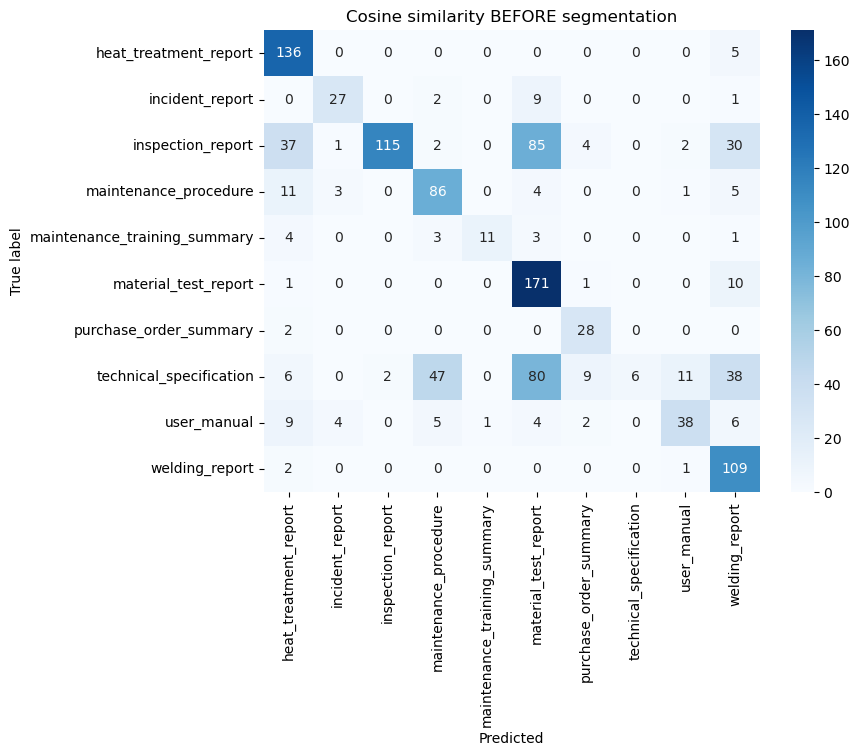

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(confu_mat, annot=True, xticklabels=class_names, yticklabels=class_names, cmap="Blues", fmt="d")

plt.ylabel("True label")
plt.xlabel("Predicted")
plt.title("Cosine similarity BEFORE segmentation")
plt.show()

---
## New function for segmenting the documents without backtracking:

In [55]:
# Auxiliary function for the following function.
def _next_usable_labels(df: pd.DataFrame, start_idx: int, k: int) -> list[str]:
    """
    Returns up to k labels of usable pages. Looking forward from start_idx (excluding start_idx).
    """
    labels = []
    for j in range(start_idx + 1, len(df)): # +1 because we want the upcoming pages. Don't care about the current one.
        if df.loc[j, "usable"]:
            labels.append(df.loc[j, "label"])
            if len(labels) >= k:
                break
    return labels

def _segment_labels_no_backtracking(df_doc: pd.DataFrame, 
                                   lookahead_usable: int = 2, 
                                   min_agreement: int = 2,
                                   keep_original_for_unusable: bool = False,
                                   forbid_return_to_used_labels: bool = True) -> pd.DataFrame:
    """
    Creates a column 'segment_label' where:
      - There is no coming back to previous labels (contiguous segments).
      - Unusable pages do not trigger changes.
      - A change is only confirmed if there is support in upcoming usable pages.
      
    Input: DataFrame where each row is a page of the same document.
    Output: Returns the same DataFrame with a new column 'segment_label'.

    The 'keep_original_for_unusable' argument:
      - When False: unusable pages inherit current_label (useful for continuous segmentation).
      - When True: unusable pages conserve their original label, but still do not trigger changes.
    """
    
    df = df_doc.sort_values("page_idx").reset_index(drop=True).copy() # Just a sanity check, pages should already be in order.

    # Find initial label: first usable.
    current_segm_label: None | str = None # This variable holds the current segment-label.
    
    for i in range(len(df)):
        if df.usable[i]:
            current_segm_label = df.label[i]
            break

    # If there are no usable pages, do nothing. Most likely, the code will not reach this point.
    if current_segm_label is None:
        df["segment_label"] = df["label"]
        df["segment_change_at"] = False
        return df

    used_labels: set[str] = {current_segm_label}
    segmented: list[str] = []
    changed_flags: list[bool] = []

    # -------------------------------------------------------------------------------------
    # This is where the segmentation logic happens:
    # -------------------------------------------------------------------------------------
    for i in range(len(df)):
        usable = df.usable[i]
        orig_label = df.label[i] # Original label of the currently inspected page.

        # Not usable page:
        if not usable:
            # Doesn't trigger any changes.
            if keep_original_for_unusable: # User preference. False by default.
                segmented.append(orig_label)
            else:
                segmented.append(current_segm_label)
            changed_flags.append(False)
            continue

        # Usable page from now on:
        if orig_label == current_segm_label: # The page's label matches the current segment label.
            segmented.append(current_segm_label)
            changed_flags.append(False)
            continue
        
        # If coming back to used labels is forbidden, label with the current segment label.
        if forbid_return_to_used_labels and orig_label in used_labels:
            segmented.append(current_segm_label)
            changed_flags.append(False)
            continue

        # Here we find how many upcoming usable pages are in the lookahead window
        future = _next_usable_labels(df, i, lookahead_usable) # list of the upcoming usable labels.

        # - If there is not enough usable pages ahead, we can:
        #   (a) Do not change (conservative) or (b) change anyway. Here I do it conservative.

        # Enter this 'if' if at least one page in the window is not usable.
        if len(future) < lookahead_usable: # Is telling that all of the labels need to be usable to consider a change.
            segmented.append(current_segm_label) # No changes, keep current label.
            changed_flags.append(False)
            continue
        
        # NOTE: So far it is been requested for all the pages in the window to be usable to consider a change.
        # This can be adjusted for example by using a bigger window and a accepting some unusable pages.
        
        """How many pages in the future match the label of the currently inspected page:"""
        agreement = sum(1 for lab in future if lab == orig_label) # Generates a list of 1s ([1,1,...]) and sum them all.

        if agreement >= min_agreement:
            # Change confirmed
            current_segm_label = orig_label
            used_labels.add(current_segm_label) # Mark this label as used.
            segmented.append(current_segm_label)
            changed_flags.append(True)
        else:
            # We treat it as noise, keep previous label
            segmented.append(current_segm_label)
            changed_flags.append(False)

    df["segment_label"] = segmented
    df["segment_change_at"] = changed_flags
    return df


#### Create the new columns on the data frame by applying the segmentation rule over all the documents:

In [56]:
df_cosine_segm = (
    df_cosine
    .groupby("doc_path", group_keys=False)
    .apply(lambda g: _segment_labels_no_backtracking(g,
                                                    lookahead_usable=LOOKAHEAD_USABLE,
                                                    min_agreement=MIN_AGREEMENT,
                                                    keep_original_for_unusable=False
                                                    )
           ))


C:\Users\sergi\AppData\Local\Temp\ipykernel_27496\44407583.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _segment_labels_no_backtracking(g,


In [57]:
''' Run this cell again to restart the iterator'''
all_paths = df_cosine_segm.doc_path.unique()
dfs = iter(all_paths)

In [58]:
''' Run this cell multiple times to see the different documents segmented data frames. '''
df_cosine_segm[df_cosine_segm.doc_path == next(dfs)]
# Explore the first 4 docs at least

,doc_name,doc_path,page_idx,text_len,label,confidence,usable,segment_label,segment_change_at
0,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1,1697,maintenance_procedure,0.396810,True,maintenance_procedure,False
1,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,2,858,welding_report,0.418874,True,maintenance_procedure,False
2,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3,3540,material_test_report,0.341514,True,maintenance_procedure,False
3,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,4,141,purchase_order_summary,0.323846,True,maintenance_procedure,False
4,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,5,1382,material_test_report,0.463104,True,maintenance_procedure,False
5,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,6,1626,maintenance_procedure,0.345257,True,maintenance_procedure,False
6,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,7,1988,user_manual,0.284366,True,maintenance_procedure,False
7,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,8,1378,welding_report,0.609989,True,welding_report,True
8,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,9,2001,welding_report,0.530969,True,welding_report,False
9,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,10,1811,welding_report,0.565283,True,welding_report,False


### The complete DF with all the documents with their original labels and the <span style='color:yellow'> segmentated labels </span>:

In [59]:
df_cosine_segm

,doc_name,doc_path,page_idx,text_len,label,confidence,usable,segment_label,segment_change_at
0,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1,1697,maintenance_procedure,0.396810,True,maintenance_procedure,False
1,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,2,858,welding_report,0.418874,True,maintenance_procedure,False
2,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3,3540,material_test_report,0.341514,True,maintenance_procedure,False
3,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,4,141,purchase_order_summary,0.323846,True,maintenance_procedure,False
4,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,5,1382,material_test_report,0.463104,True,maintenance_procedure,False
...,...,...,...,...,...,...,...,...,...
21,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,22,2380,material_test_report,0.500509,True,material_test_report,False
22,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,23,2593,material_test_report,0.395562,True,material_test_report,False
23,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,24,2438,material_test_report,0.623185,True,material_test_report,False
24,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,25,3193,material_test_report,0.479501,True,material_test_report,False


In [60]:
vc_label = df_cosine.label.value_counts()
vc_segment = df_cosine_segm.segment_label.value_counts()
df_counts = pd.concat([vc_label, vc_segment], axis=1, keys=["label", "segment_label"]).fillna(0).astype(int)
df_counts

,label,segment_label
material_test_report,356,341
heat_treatment_report,208,198
welding_report,205,206
maintenance_procedure,145,158
inspection_report,117,137
user_manual,53,51
purchase_order_summary,44,38
incident_report,35,26
maintenance_training_summary,12,6
technical_specification,6,20


# Cosine Similarity Performance <span style='color:red'> After Segmentation </span>:

In [61]:
accuracy_score(target_df.target_label, df_cosine_segm.segment_label) # (y_true, y_pred)

0.5935647756138865

In [62]:
print(classification_report(target_df.target_label, df_cosine_segm.segment_label)) # (y_true, y_pred)

                              precision    recall  f1-score   support

       heat_treatment_report       0.62      0.87      0.73       141
             incident_report       0.85      0.56      0.68        39
           inspection_report       0.85      0.42      0.57       276
       maintenance_procedure       0.50      0.72      0.59       110
maintenance_training_summary       1.00      0.27      0.43        22
        material_test_report       0.47      0.88      0.61       183
      purchase_order_summary       0.74      0.93      0.82        30
     technical_specification       0.80      0.08      0.15       199
                 user_manual       0.94      0.70      0.80        69
              welding_report       0.49      0.90      0.64       112

                    accuracy                           0.59      1181
                   macro avg       0.73      0.63      0.60      1181
                weighted avg       0.70      0.59      0.55      1181



In [63]:
confu_mat = confusion_matrix(target_df.target_label, df_cosine_segm.segment_label) # confusion_matrix(y_true, y_pred)

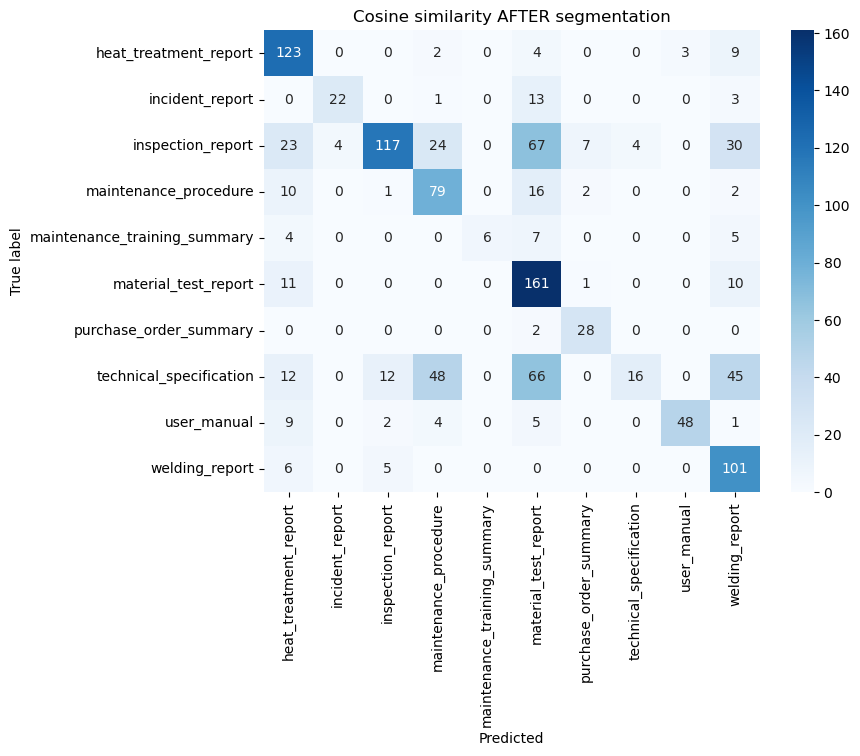

In [64]:
plt.figure(figsize=(8,6))
sns.heatmap(confu_mat, annot=True, xticklabels=class_names, yticklabels=class_names, cmap="Blues", fmt="d")

plt.ylabel("True label")
plt.xlabel("Predicted")
plt.title("Cosine similarity AFTER segmentation")
plt.show()

### "first and last page" DataFrame

In [65]:
df_cosine_segm_summary = (df_cosine_segm
                             .groupby(["doc_path", "segment_label"], as_index=False, sort=False) # Keep keys as columns
                             .agg(first_page=("page_idx", "min"),
                                  last_page=("page_idx", "max"),
                                  n_pages=("page_idx", "count"))
                             )
# Add a column with the total number of pages in the document:
df_cosine_segm_summary["total_pages_doc"] = (df_cosine_segm_summary
                                                 .groupby("doc_path")["last_page"]
                                                 .transform("max")
                                                 )
df_cosine_segm_summary["label_ratio"] = (df_cosine_segm_summary.n_pages / 
                                                 df_cosine_segm_summary.total_pages_doc
                                                 ).round(2)

In [66]:
df_cosine_segm_summary

,doc_path,segment_label,first_page,last_page,n_pages,total_pages_doc,label_ratio
0,..\data - ground_truth\PO-2025-001\FS-001\Engi...,maintenance_procedure,1,7,7,12,0.58
1,..\data - ground_truth\PO-2025-001\FS-001\Engi...,welding_report,8,12,5,12,0.42
2,..\data - ground_truth\PO-2025-001\FS-001\Main...,maintenance_procedure,1,10,10,17,0.59
3,..\data - ground_truth\PO-2025-001\FS-001\Main...,material_test_report,11,17,7,17,0.41
4,..\data - ground_truth\PO-2025-001\FS-001\Qual...,material_test_report,1,11,11,11,1.00
...,...,...,...,...,...,...,...
143,..\data - ground_truth\PO-2025-003\Misc\FS-005...,incident_report,1,9,9,9,1.00
144,..\data - ground_truth\PO-2025-003\PO-2025-003...,purchase_order_summary,1,15,15,15,1.00
145,..\data - ground_truth\PO-2025-003\Shared\FS-0...,inspection_report,1,11,11,26,0.42
146,..\data - ground_truth\PO-2025-003\Shared\FS-0...,welding_report,12,19,8,26,0.31


---
---
# KMeans Clustering Approach
---
---

In [67]:
# Copy the original dataframe
df_kmeans = df_cosine[["doc_name", "doc_path", "text_len", "page_idx"]].copy()

In [68]:
def cluster_pages_kmeans_seeded( page_embs: np.ndarray,
                                type_centroids: np.ndarray,
                                random_state: int = 42,
                                max_iter: int = 300) -> tuple[np.ndarray, object]:
    """
    Clusteriza páginas usando KMeans, inicializando centros con los centroides de doc-types.
    Retorna cluster_id por página (0..k-1).
    """
    try:
        from sklearn.cluster import KMeans
    except ImportError:
        raise ImportError("Install scikit-learn: pip install scikit-learn")
    
    
    k = type_centroids.shape[0]
    km = KMeans( n_clusters=k,
                init=type_centroids,   # seeded
                n_init=1,              # important: no re-initialize, we want to keep the seeded centroids as they are.
                max_iter=max_iter,
                random_state=random_state,
                algorithm="lloyd" )
    
    cluster_ids = km.fit_predict(page_embs)
    return cluster_ids, km


In [69]:
cluster_ids, km_model = cluster_pages_kmeans_seeded(page_embs, type_centroids, random_state=SEED)

c:\Users\sergi\Anaconda\anaconda3\envs\doc_embeddings\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


### Check how many pages ended up in each cluster:

In [70]:
counts = np.bincount(cluster_ids)

for i, c in enumerate(counts):
    print(f"Cluster {i}: {c} pages")

Cluster 0: 69 pages
Cluster 1: 173 pages
Cluster 2: 246 pages
Cluster 3: 178 pages
Cluster 4: 140 pages
Cluster 5: 108 pages
Cluster 6: 69 pages
Cluster 7: 135 pages
Cluster 8: 42 pages
Cluster 9: 21 pages


In [71]:
df_kmeans["cluster_id"] = cluster_ids
df_kmeans["cluster_id"].value_counts().sort_index()

cluster_id
0     69
1    173
2    246
3    178
4    140
5    108
6     69
7    135
8     42
9     21
Name: count, dtype: int64

How many elements where classified:

In [72]:
cluster_ids.shape

(1181,)

5 centroids (one for each cluster), each of them of dimension 384:

In [73]:
km_model.cluster_centers_

array([[-0.09961636,  0.03106277, -0.00641475, ...,  0.01247171,
         0.00127648, -0.00608623],
       [-0.14970946,  0.04076816,  0.01410552, ...,  0.00195532,
        -0.0091562 ,  0.00291205],
       [-0.08578581,  0.0447648 ,  0.05252381, ..., -0.01632518,
        -0.03763755,  0.02261378],
       ...,
       [-0.1216187 ,  0.02841975,  0.00561254, ..., -0.00224168,
        -0.03250876,  0.0084195 ],
       [-0.10569638,  0.02773112, -0.00646765, ...,  0.00237605,
        -0.03685316,  0.02007288],
       [-0.11850548,  0.02244213,  0.02110973, ..., -0.00744841,
        -0.03834875, -0.01052955]], shape=(10, 384), dtype=float32)

In [74]:
# Chech the API of KMeans:
[m for m in dir(km_model) if not m.startswith("_")]

['algorithm',
 'cluster_centers_',
 'copy_x',
 'fit',
 'fit_predict',
 'fit_transform',
 'get_feature_names_out',
 'get_metadata_routing',
 'get_params',
 'inertia_',
 'init',
 'labels_',
 'max_iter',
 'n_clusters',
 'n_features_in_',
 'n_init',
 'n_iter_',
 'predict',
 'random_state',
 'score',
 'set_fit_request',
 'set_output',
 'set_params',
 'set_score_request',
 'tol',
 'transform',
 'verbose']

### Retrieve and normalize the cluster centers
- Normalization is needed again, since the cluster center is an average of all the points inside it, so mostlikely it would be a value inside the hypersphere. We need to push this value back to the surface of the hypersphere.

In [75]:
cluster_centroids = km_model.cluster_centers_
# Normalization This is necessary since we are using cosine similarity:
cluster_centroids = cluster_centroids / (np.linalg.norm(cluster_centroids, axis=1, keepdims=True) + 1e-12)
cluster_centroids.shape

(10, 384)

In [76]:
def map_clusters_to_types( cluster_centroids: np.ndarray,
                          type_centroids: np.ndarray,
                          type_names: list[str] ) -> tuple[dict[int, str], pd.DataFrame]:
    """
    returns:
      - mapping: cluster_id -> doc_type
      - df_scores: Similarity between cluster x type. How close is each cluster to each type?
    """
    sims = cluster_centroids @ type_centroids.T  # Shape should be k*k for k = # of types
    df_scores = pd.DataFrame(sims, columns=type_names)
    df_scores.insert(0, "cluster_id", np.arange(len(cluster_centroids)))

    mapping = {}
    for i in range(len(cluster_centroids)):
        row = df_scores.loc[i, type_names]
        if row.isna().all():
            mapping[i] = "unknown"
        else:
            mapping[i] = row.idxmax()
    return mapping, df_scores


In [77]:
cluster_to_type, df_cluster_type_scores = map_clusters_to_types(cluster_centroids, type_centroids, type_names)

display(cluster_to_type)
df_cluster_type_scores.round(3)

{0: 'purchase_order_summary',
 1: 'material_test_report',
 2: 'material_test_report',
 3: 'material_test_report',
 4: 'heat_treatment_report',
 5: 'maintenance_procedure',
 6: 'user_manual',
 7: 'welding_report',
 8: 'incident_report',
 9: 'maintenance_training_summary'}

,cluster_id,purchase_order_summary,technical_specification,inspection_report,material_test_report,heat_treatment_report,maintenance_procedure,user_manual,welding_report,incident_report,maintenance_training_summary
0,0,0.496,0.362,0.392,0.387,0.353,0.420,0.371,0.439,0.392,0.340
1,1,0.301,0.342,0.318,0.422,0.340,0.371,0.337,0.394,0.339,0.283
2,2,0.282,0.293,0.475,0.479,0.429,0.370,0.363,0.437,0.361,0.350
3,3,0.230,0.278,0.350,0.641,0.480,0.245,0.306,0.428,0.319,0.260
4,4,0.210,0.175,0.240,0.458,0.663,0.283,0.273,0.406,0.255,0.238
5,5,0.307,0.235,0.336,0.388,0.399,0.503,0.377,0.394,0.427,0.397
6,6,0.284,0.267,0.274,0.348,0.336,0.383,0.439,0.398,0.345,0.336
7,7,0.242,0.262,0.323,0.395,0.422,0.330,0.316,0.668,0.348,0.332
8,8,0.359,0.298,0.420,0.413,0.408,0.427,0.336,0.429,0.534,0.408
9,9,0.298,0.309,0.385,0.447,0.446,0.514,0.472,0.449,0.439,0.570


---
### Fixing overlapping clusters:

In [78]:
def _find_overlapping_clusters( mapping: dict[int, str] ) -> dict[str, list[int]]:
    """ returns a dict where the keys are the doc-types and the values are the list of overlapping clusters. """
    groups = defaultdict(list) # dict of lists

    for cluster_id, types, in mapping.items():
        # The keys now are the doc-types. Every time the same doc-type is found, it is added to the list.
        groups[types].append(cluster_id)
        
    return {v: ks for v, ks in groups.items() if len(ks) > 1} # filter out singletons.

_find_overlapping_clusters(cluster_to_type)

{'material_test_report': [1, 2, 3]}

In [79]:
def _hungarian_remapping(scores: pd.DataFrame, mapping: dict[int, str]) -> dict[int, str]:
    """ Uses the Hungarian algorithm to maximes the similarity between clusters and doc-types JUST WHERE CLUSTERS OVERLAPPED. """
    new_mapping = mapping.copy()
    # Each v is one list of overlapping clusters
    for v in _find_overlapping_clusters(mapping).values():
        # sub matrix with only overlapping clusters
        # - 'cluster_id' column is dropped to have a square matrix
        # - inplace = False -> returns a copy
        # - reset_index(drop=True) -> because 'cluster_id' was dropped
        sub_scores = scores.drop(columns='cluster_id', inplace=False).reset_index(drop=True).iloc[v,v]
        
        display(Markdown('### Sub matrix of overlapping scores:'))
        display(sub_scores)
        
        rows, cols = linear_sum_assignment(sub_scores, maximize=True)

        for i, j in zip(sub_scores.index, cols):
            new_mapping[int(i)] = sub_scores.columns[j]

    return new_mapping

In [80]:
cluster_to_type = _hungarian_remapping(df_cluster_type_scores, cluster_to_type)
cluster_to_type

### Sub matrix of overlapping scores:

,technical_specification,inspection_report,material_test_report
1,0.341693,0.318449,0.422091
2,0.293144,0.475309,0.478599
3,0.278057,0.350354,0.640621


{0: 'purchase_order_summary',
 1: 'technical_specification',
 2: 'inspection_report',
 3: 'material_test_report',
 4: 'heat_treatment_report',
 5: 'maintenance_procedure',
 6: 'user_manual',
 7: 'welding_report',
 8: 'incident_report',
 9: 'maintenance_training_summary'}

---

### Data Frame with the k-means labels:

In [81]:
df_kmeans["label_kmeans"] = df_kmeans["cluster_id"].map(cluster_to_type)
df_kmeans["usable"] = (df_kmeans["text_len"] > 50)
df_kmeans

,doc_name,doc_path,text_len,page_idx,cluster_id,label_kmeans,usable
0,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1697,1,1,technical_specification,True
1,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,858,2,0,purchase_order_summary,True
2,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3540,3,1,technical_specification,True
3,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,141,4,0,purchase_order_summary,True
4,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1382,5,2,inspection_report,True
...,...,...,...,...,...,...,...
1176,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,2380,22,3,material_test_report,True
1177,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,2593,23,3,material_test_report,True
1178,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,2438,24,3,material_test_report,True
1179,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,3193,25,3,material_test_report,True


In [82]:
vc_label_cosine = df_cosine.label.value_counts()
vc_segment_cosine = df_cosine_segm.segment_label.value_counts()
vc_label_kmeans = df_kmeans.label_kmeans.value_counts()
df_counts = pd.concat([vc_label, vc_label_kmeans, vc_segment], axis=1, keys=["label_cosine", "label_kmeans", "segment_label_cosine"]).fillna(0).astype(int)
df_counts

,label_cosine,label_kmeans,segment_label_cosine
material_test_report,356,178,341
heat_treatment_report,208,140,198
welding_report,205,135,206
maintenance_procedure,145,108,158
inspection_report,117,246,137
user_manual,53,69,51
purchase_order_summary,44,69,38
incident_report,35,42,26
maintenance_training_summary,12,21,6
technical_specification,6,173,20


# K-means Performance <span style='color:red'> Before Segmentation </span>:

In [83]:
accuracy_score(target_df.target_label, df_kmeans.label_kmeans) # (y_true, y_pred)

0.9322607959356477

In [84]:
print(classification_report(target_df.target_label, df_kmeans.label_kmeans)) # (y_true, y_pred)

                              precision    recall  f1-score   support

       heat_treatment_report       0.97      0.96      0.97       141
             incident_report       0.93      1.00      0.96        39
           inspection_report       1.00      0.89      0.94       276
       maintenance_procedure       0.99      0.97      0.98       110
maintenance_training_summary       1.00      0.95      0.98        22
        material_test_report       0.98      0.96      0.97       183
      purchase_order_summary       0.42      0.97      0.59        30
     technical_specification       0.99      0.86      0.92       199
                 user_manual       0.99      0.99      0.99        69
              welding_report       0.81      0.97      0.88       112

                    accuracy                           0.93      1181
                   macro avg       0.91      0.95      0.92      1181
                weighted avg       0.95      0.93      0.94      1181



In [85]:
confu_mat = confusion_matrix(target_df.target_label, df_kmeans.label_kmeans) # confusion_matrix(y_true, y_pred)

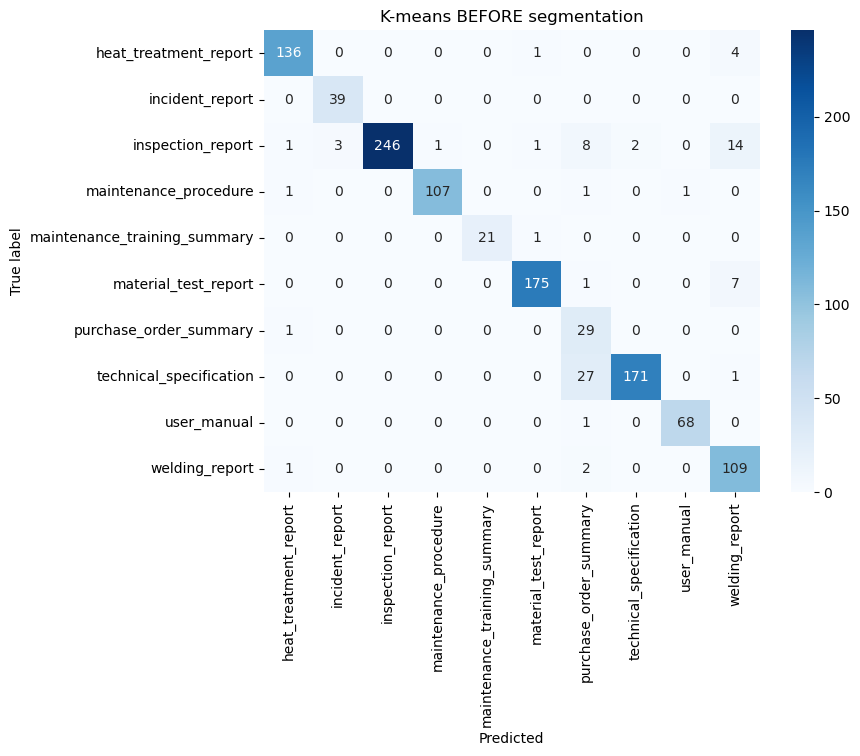

In [86]:
plt.figure(figsize=(8,6))
sns.heatmap(confu_mat, annot=True, xticklabels=class_names, yticklabels=class_names, cmap="Blues", fmt="d")

plt.ylabel("True label")
plt.xlabel("Predicted")
plt.title("K-means BEFORE segmentation")
plt.show()

# K-means Performance <span style='color:red'> After Segmentation </span>:

In [118]:
# Rename columns just for the segmentation
df_kmeans = df_kmeans.rename(columns={"label_kmeans": "label"})

In [119]:
df_kmeans_segm = (
    df_kmeans
    .groupby("doc_path", group_keys=False)
    .apply(lambda g: _segment_labels_no_backtracking(g.assign(doc_path=g.name),
                                                    lookahead_usable=LOOKAHEAD_USABLE,
                                                    min_agreement=MIN_AGREEMENT,
                                                    keep_original_for_unusable=False
                                                    )
           ))

C:\Users\sergi\AppData\Local\Temp\ipykernel_27496\3195650374.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _segment_labels_no_backtracking(g.assign(doc_path=g.name),


In [120]:
# Rename columns back to "label_kmeans"
df_kmeans = df_kmeans.rename(columns={"label": "label_kmeans"})
df_kmeans_segm = df_kmeans_segm.rename(columns={"label": "label_kmeans", "segment_label": "segment_label_kmeans"})

In [121]:
df_kmeans_segm

,doc_name,doc_path,text_len,page_idx,cluster_id,label_kmeans,usable,segment_label_kmeans,segment_change_at
0,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1697,1,1,technical_specification,True,technical_specification,False
1,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,858,2,0,purchase_order_summary,True,technical_specification,False
2,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,3540,3,1,technical_specification,True,technical_specification,False
3,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,141,4,0,purchase_order_summary,True,technical_specification,False
4,SYN-2025-8182 - Technical Specification FS-001,..\data - ground_truth\PO-2025-001\FS-001\Engi...,1382,5,2,inspection_report,True,technical_specification,False
...,...,...,...,...,...,...,...,...,...
21,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,2380,22,3,material_test_report,True,material_test_report,False
22,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,2593,23,3,material_test_report,True,material_test_report,False
23,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,2438,24,3,material_test_report,True,material_test_report,False
24,FS-005_Inspection_Report_R2,..\data - ground_truth\PO-2025-003\Shared\FS-0...,3193,25,3,material_test_report,True,material_test_report,False


In [243]:
accuracy_score(target_df.target_label, df_kmeans_segm.segment_label_kmeans) # (y_true, y_pred)

0.8729889923793396

In [244]:
print(classification_report(target_df.target_label, df_kmeans_segm.segment_label_kmeans)) # (y_true, y_pred)

                              precision    recall  f1-score   support

       heat_treatment_report       0.88      0.87      0.88       141
             incident_report       0.89      0.85      0.87        39
           inspection_report       0.91      0.84      0.87       276
       maintenance_procedure       0.96      0.90      0.93       110
maintenance_training_summary       1.00      0.77      0.87        22
        material_test_report       0.92      0.90      0.91       183
      purchase_order_summary       0.68      0.93      0.79        30
     technical_specification       0.85      0.80      0.83       199
                 user_manual       0.93      0.93      0.93        69
              welding_report       0.73      0.97      0.83       112

                    accuracy                           0.87      1181
                   macro avg       0.87      0.88      0.87      1181
                weighted avg       0.88      0.87      0.87      1181



In [245]:
confu_mat = confusion_matrix(target_df.target_label, df_kmeans_segm.segment_label_kmeans) # confusion_matrix(y_true, y_pred)

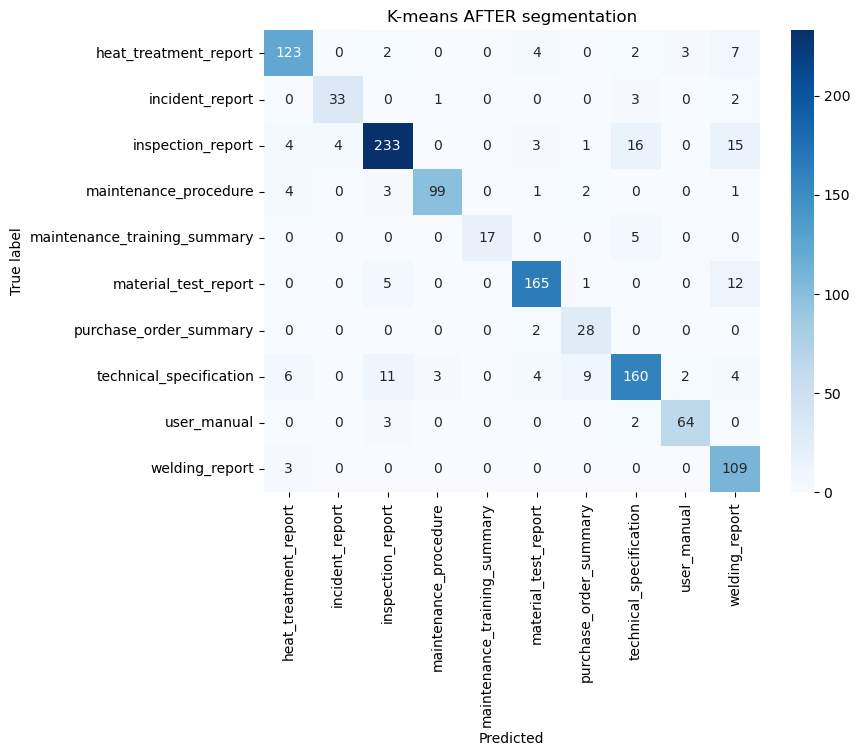

In [246]:
plt.figure(figsize=(8,6))
sns.heatmap(confu_mat, annot=True, xticklabels=class_names, yticklabels=class_names, cmap="Blues", fmt="d")

plt.ylabel("True label")
plt.xlabel("Predicted")
plt.title("K-means AFTER segmentation")
plt.show()

### "first and last page" DataFrame

In [247]:
df_kmeans_segm_summary = (df_kmeans_segm
                             .groupby(["doc_path", "segment_label_kmeans"], as_index=False, sort=False) # Keep keys as columns
                             .agg(first_page=("page_idx", "min"),
                                  last_page=("page_idx", "max"),
                                  n_pages=("page_idx", "count"))
                             )
# Add a column with the total number of pages in the document:
df_kmeans_segm_summary["total_pages_doc"] = (df_kmeans_segm_summary
                                                 .groupby("doc_path")["last_page"]
                                                 .transform("max")
                                                 )
df_kmeans_segm_summary["label_ratio"] = (df_kmeans_segm_summary.n_pages / 
                                                 df_kmeans_segm_summary.total_pages_doc
                                                 ).round(2)

In [22]:
list(range(3,7))

[3, 4, 5, 6]

In [248]:
df_kmeans_segm_summary

,doc_path,segment_label_kmeans,first_page,last_page,n_pages,total_pages_doc,label_ratio
0,..\data - ground_truth\PO-2025-001\FS-001\Engi...,technical_specification,1,7,7,12,0.58
1,..\data - ground_truth\PO-2025-001\FS-001\Engi...,welding_report,8,12,5,12,0.42
2,..\data - ground_truth\PO-2025-001\FS-001\Main...,maintenance_procedure,1,10,10,17,0.59
3,..\data - ground_truth\PO-2025-001\FS-001\Main...,material_test_report,11,17,7,17,0.41
4,..\data - ground_truth\PO-2025-001\FS-001\Qual...,material_test_report,1,6,6,11,0.55
...,...,...,...,...,...,...,...
168,..\data - ground_truth\PO-2025-003\PO-2025-003...,purchase_order_summary,1,9,9,15,0.60
169,..\data - ground_truth\PO-2025-003\PO-2025-003...,inspection_report,10,15,6,15,0.40
170,..\data - ground_truth\PO-2025-003\Shared\FS-0...,inspection_report,1,12,12,26,0.46
171,..\data - ground_truth\PO-2025-003\Shared\FS-0...,welding_report,13,19,7,26,0.27


---
---
# SVM Approach
---
---

In [249]:
page_records_train = build_page_records(train_files)
page_records_val = build_page_records(val_files)
page_records_test = build_page_records(test_files)

In [250]:
train_texts = [p.text for p in page_records_train]
train_embs = embedder.embed(train_texts)

val_texts = [p.text for p in page_records_val]
val_embs = embedder.embed(val_texts)

test_texts = [p.text for p in page_records_test]
test_embs = embedder.embed(test_texts)

Batches: 100%|██████████| 4/4 [00:05<00:00,  1.34s/it]


In [251]:
train_embs.shape, val_embs.shape, test_embs.shape

((943, 384), (122, 384), (116, 384))

In [252]:
def svm_classifier(train_embs : np.ndarray, train_labels : pd.Series,
                    val_embs : np.ndarray,
                    test_embs : np.ndarray,
                    kernel : str = "linear", C : float = 1.0) -> tuple[np.ndarray, np.ndarray, object]:
    try:
        from sklearn.svm import SVC
    except ImportError:
        raise ImportError("Install scikit-learn: pip install scikit-learn")
    
    svc = SVC(kernel=kernel, C=C, class_weight="balanced") # Classes are unbalanced.
    
    svc.fit(train_embs, train_labels)
    
    y_pred_val = svc.predict(val_embs)
    y_pred_test = svc.predict(test_embs)
    
    return y_pred_val, y_pred_test, svc

In [253]:
y_pred_val, y_pred_test, svc = svm_classifier(train_embs, y_train.target_label, val_embs, test_embs)

In [254]:
y_pred = np.concatenate([y_pred_val, y_pred_test])
y_true = np.concatenate([y_val.target_label, y_test.target_label])

y_pred.shape, y_true.shape

((238,), (238,))

In [255]:
accuracy_score(y_true, y_pred)

0.9915966386554622

In [256]:
print(classification_report(y_true, y_pred))

                              precision    recall  f1-score   support

       heat_treatment_report       1.00      1.00      1.00        29
             incident_report       1.00      1.00      1.00         1
           inspection_report       1.00      0.98      0.99        64
       maintenance_procedure       1.00      1.00      1.00        22
maintenance_training_summary       1.00      1.00      1.00         7
        material_test_report       1.00      0.97      0.98        33
     technical_specification       0.97      1.00      0.98        63
                 user_manual       1.00      1.00      1.00        16
              welding_report       1.00      1.00      1.00         3

                    accuracy                           0.99       238
                   macro avg       1.00      0.99      1.00       238
                weighted avg       0.99      0.99      0.99       238



In [257]:
confu_mat = confusion_matrix(y_true, y_pred)

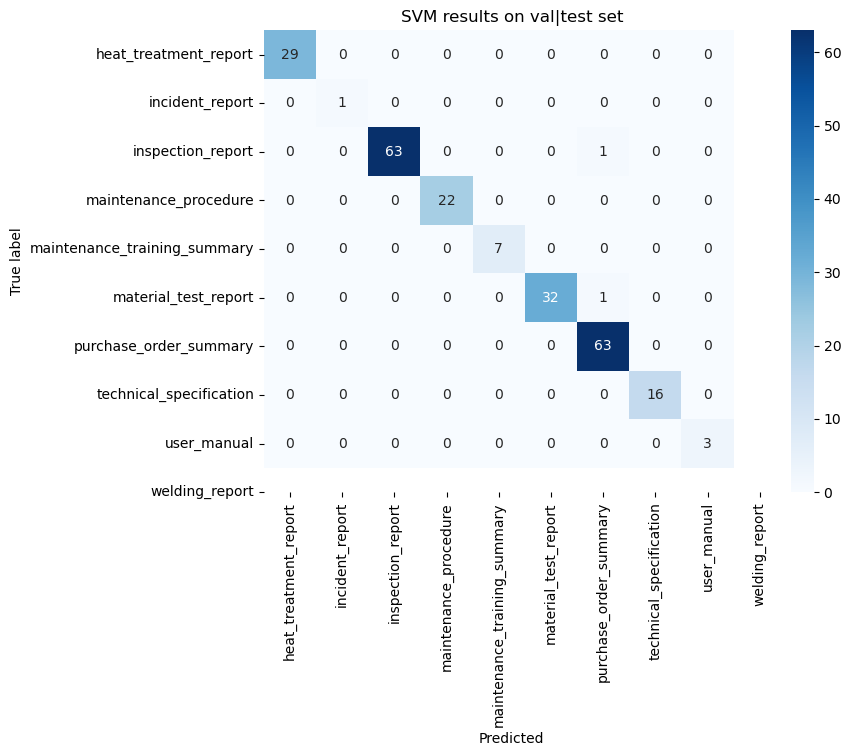

In [258]:
plt.figure(figsize=(8,6))
sns.heatmap(confu_mat, annot=True, xticklabels=class_names, yticklabels=class_names, cmap="Blues", fmt="d")

plt.ylabel("True label")
plt.xlabel("Predicted")
plt.title("SVM results on val|test set")
plt.show()

---
---
# HDBSCAN (No k needed)
---
---

The **core distance**, denoted as $core_k(x)$, is <span style="color:yellow"> the distance from x to the k-th nearest neighbor </span>. A smaller core distance suggests a **more dense area**, while a larger core distance suggests a **more sparse area**. k is the parameter defined by `min_samples` in the HDBSCAN algorithm.

**Mutual reachability distance** between two points a and b is defined as:

$$
d_{mre}(a,b) = \max\{core_k(a), core_k(b), d(a,b)\}
$$

In [259]:
def cluster_pages_hdbscan(page_embs: np.ndarray,
                          min_cluster_size: int = 15,
                          min_samples: int | None = None, # Uses min_cluster_size if None. Is a common heuristic.
                          metric: str = "euclidean") -> tuple[np.ndarray, object]:
    try:
        from hdbscan import HDBSCAN
    except ImportError:
        raise ImportError("Install hdbscan: pip install hdbscan")

    model = HDBSCAN(min_cluster_size=min_cluster_size,
                    min_samples=min_samples,
                    metric=metric,
                    cluster_selection_method="eom",
                    prediction_data=False)
    
    cluster_ids = model.fit_predict(page_embs)  # -1 = outlier
    return cluster_ids, model

In [260]:
cluster_ids_hdbscan, hdbscan = cluster_pages_hdbscan(page_embs, min_cluster_size=15, min_samples=15)

print(cluster_ids_hdbscan.shape)
hdbscan

(1181,)


,min_cluster_size,15
,min_samples,15
,cluster_selection_epsilon,0.0
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


#### Condensed Tree 
 #### core distance with k=15:

<Axes: ylabel='$\\lambda$ value'>

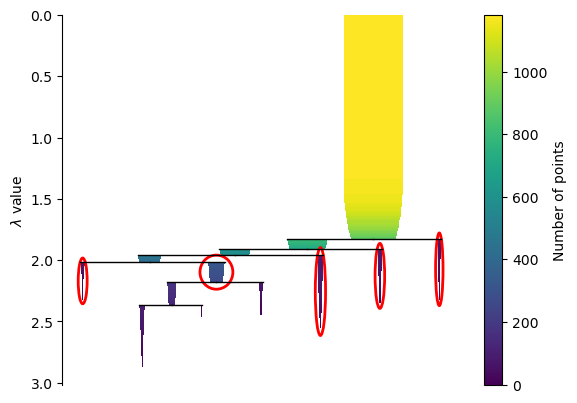

In [261]:
display(Markdown("#### Condensed Tree \n #### core distance with k=15:"))
hdbscan.condensed_tree_.plot(select_clusters=True)

In [262]:
values, counts = np.unique(cluster_ids_hdbscan, return_counts=True) # cluster ids assigned to each page, -1 means outlier
for val, count in zip(values, counts):
    print(f"Cluster {val}: {count} pages") # -1 is outlier

Cluster -1: 494 pages
Cluster 0: 74 pages
Cluster 1: 95 pages
Cluster 2: 102 pages
Cluster 3: 89 pages
Cluster 4: 327 pages


#### Condensed Tree: 
 $k=1 \hspace{0.3cm} \Rightarrow \hspace{0.3cm} d_{mre}(a,b) = d(a,b$)

<Axes: ylabel='$\\lambda$ value'>

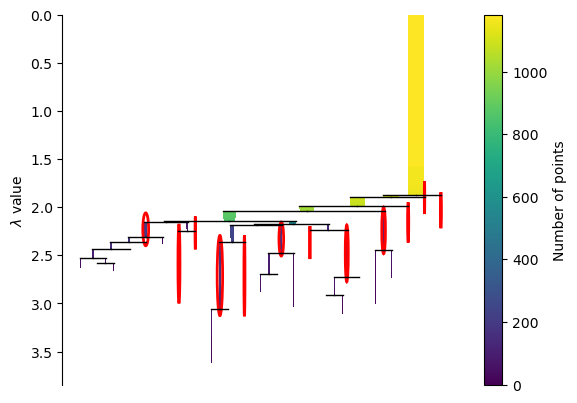

In [263]:
cluster_ids_hdbscan, hdbscan = cluster_pages_hdbscan(page_embs, min_cluster_size=15, min_samples=1)
display(Markdown("#### Condensed Tree: \n $k=1 \hspace{0.3cm} \Rightarrow \hspace{0.3cm} d_{mre}(a,b) = d(a,b$)"))
hdbscan.condensed_tree_.plot(select_clusters=True)

The initial <span style='color:yellow'> yellow column </span> represents the initial cluster where all the pages are together. Tha fact the this cluster doesn't splits until a very high $\lambda = \frac{1}{d}$, means that it is required for the pages to be very close to each other in order to be considered in the same cluster, that is, the data is very sparse and there are no natural clusters. Probably there is a lot of noise in between the clusters. In other words:

$$
\max \text{(intra cluster distance)} \approx \min \text{(inter cluster distance)}
$$
What will happen in this scenario:
- One big cluster + noise
- A lot of unstable micro-clusters
- Clusters change violently with the hyperparameters

It can be conclude that the transition between clusters is smooth, therefore, the data set **is not clusterable by density**.

$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

$$
\mathcal{N}(x \mid \mu,\sigma^2)
= \frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(-\frac{1}{2}\frac{(x-\mu)^2}{\sigma^2}\right)
$$

$$
f(x) =
\frac{1}{\sqrt{(2\pi)^d |\Sigma|}}
\exp\!\left(
-\frac{1}{2}(x-\mu)^{T}\Sigma^{-1}(x-\mu)
\right)
$$

$$
\mathcal{N}(x \mid \mu,\Sigma)
=
\frac{1}{\sqrt{(2\pi)^d |\Sigma|}}
\exp\!\left(
-\frac{1}{2}(x-\mu)^{T}\Sigma^{-1}(x-\mu)
\right)
$$